Total series length T: 54000


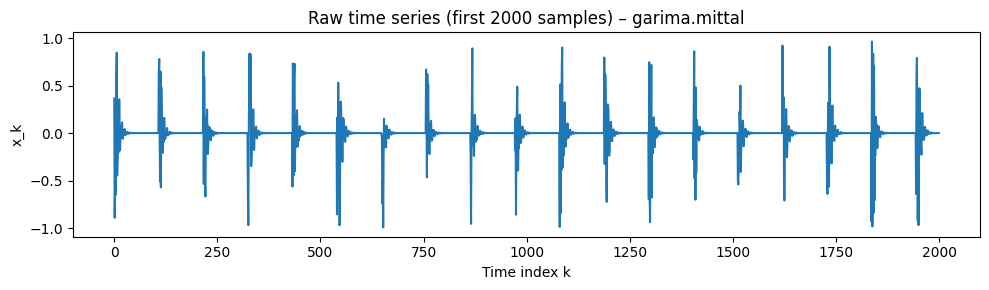

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random

GLOBAL_SEED = 2023102069
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DATA_PATH = "/kaggle/input/q2-smai/recurrence_timeseries.csv"

df = pd.read_csv(DATA_PATH)
assert "x_value" in df.columns, "Expected a column named 'x_value'."

series_raw = df["x_value"].astype(np.float32).values
T = len(series_raw)
print("Total series length T:", T)

plt.figure(figsize=(10, 3))
plt.plot(series_raw[:2000])
plt.title("Raw time series (first 2000 samples) – garima.mittal")
plt.xlabel("Time index k")
plt.ylabel("x_k")
plt.tight_layout()
plt.show()


Split lengths:
  train: 37800
  val  : 8100
  test : 8100


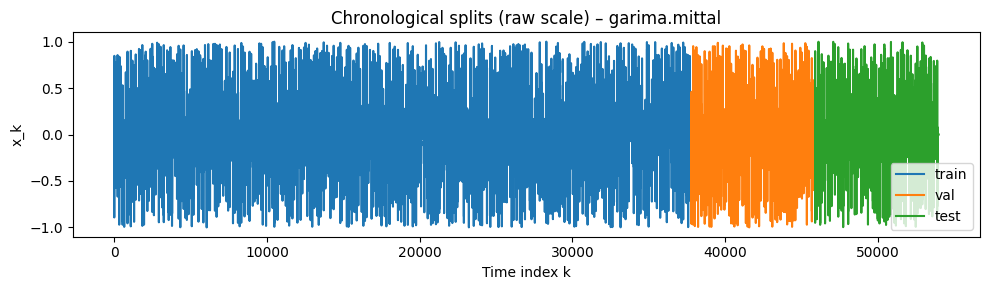

In [18]:
def chronological_splits(series, train_frac=0.7, val_frac=0.15):
    T = len(series)
    train_end = int(T * train_frac)
    val_end = train_end + int(T * val_frac)
    train = series[:train_end]
    val = series[train_end:val_end]
    test = series[val_end:]
    return train, val, test

train_raw, val_raw, test_raw = chronological_splits(series_raw,
                                                    train_frac=0.7,
                                                    val_frac=0.15)

print("Split lengths:")
print("  train:", len(train_raw))
print("  val  :", len(val_raw))
print("  test :", len(test_raw))

plt.figure(figsize=(10, 3))
plt.plot(train_raw, label="train")
plt.plot(range(len(train_raw), len(train_raw)+len(val_raw)),
         val_raw, label="val")
plt.plot(range(len(train_raw)+len(val_raw), len(series_raw)),
         test_raw, label="test")
plt.title("Chronological splits (raw scale) – garima.mittal")
plt.xlabel("Time index k")
plt.ylabel("x_k")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
def create_supervised_pairs(series_1d, history):
    x_list, y_list = [], []
    for t in range(history, len(series_1d)):
        x_list.append(series_1d[t-history:t])
        y_list.append(series_1d[t])
    X = np.stack(x_list).astype(np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y

# initial history length; will be tuned later using validation
p_init = 10

X_train_raw, y_train_raw = create_supervised_pairs(train_raw, p_init)
X_val_raw,   y_val_raw   = create_supervised_pairs(val_raw,   p_init)
X_test_raw,  y_test_raw  = create_supervised_pairs(test_raw,  p_init)

print("History length p:", p_init)
print("Supervised shapes (raw scale):")
print("  X_train:", X_train_raw.shape, "y_train:", y_train_raw.shape)
print("  X_val  :", X_val_raw.shape,   "y_val  :", y_val_raw.shape)
print("  X_test :", X_test_raw.shape,  "y_test :", y_test_raw.shape)


History length p: 10
Supervised shapes (raw scale):
  X_train: (37790, 10) y_train: (37790,)
  X_val  : (8090, 10) y_val  : (8090,)
  X_test : (8090, 10) y_test : (8090,)


Train mean: -0.0006826688186265528
Train std : 0.16140992939472198
Normalized train mean/std (approx.): -1.9174404286559366e-09 1.0


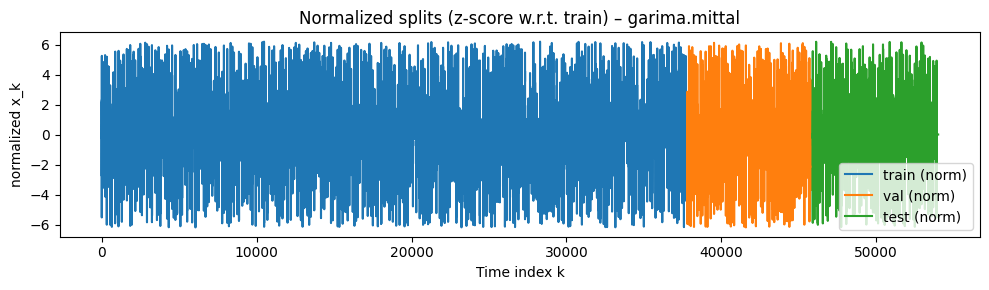

Supervised shapes (normalized):
  X_train: (37790, 10) y_train: (37790,)
  X_val  : (8090, 10) y_val  : (8090,)
  X_test : (8090, 10) y_test : (8090,)


In [20]:
mu_train = float(train_raw.mean())
sigma_train = float(train_raw.std())

print("Train mean:", mu_train)
print("Train std :", sigma_train)

def normalize(x):
    return (x - mu_train) / sigma_train

def denormalize(x_norm):
    return x_norm * sigma_train + mu_train

train = normalize(train_raw)
val   = normalize(val_raw)
test  = normalize(test_raw)

print("Normalized train mean/std (approx.):",
      float(train.mean()), float(train.std()))

plt.figure(figsize=(10, 3))
plt.plot(train, label="train (norm)")
plt.plot(range(len(train), len(train)+len(val)),
         val, label="val (norm)")
plt.plot(range(len(train)+len(val), len(series_raw)),
         test, label="test (norm)")
plt.title("Normalized splits (z-score w.r.t. train) – garima.mittal")
plt.xlabel("Time index k")
plt.ylabel("normalized x_k")
plt.legend()
plt.tight_layout()
plt.show()

X_train, y_train = create_supervised_pairs(train, p_init)
X_val,   y_val   = create_supervised_pairs(val,   p_init)
X_test,  y_test  = create_supervised_pairs(test,  p_init)

print("Supervised shapes (normalized):")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("  X_test :", X_test.shape,  "y_test :", y_test.shape)


### 2.1 Dataset and Problem Setup — Task Summary

In this section, we prepare the data for learning a discrete-time recurrence from univariate sequences.
Our goal is to construct supervised samples **(hₖ → xₖ)**, where **hₖ** is a history window of length *p*, and apply normalization suitable for training sequence models.

---

### 1. Data Splits

We create **chronological train/validation/test splits** to respect the temporal ordering of the sequence.
This avoids information leakage from the future into the past.

A typical choice is:

- **70%** for training (model learns patterns)
- **15%** for validation (hyperparameter tuning, selecting p)
- **15%** for test (final evaluation)

This ensures the model is evaluated only on unseen future data.

---

### 2. Supervised Pairs (hₖ → xₖ)

To predict the next value, we form supervised pairs:

- **hₖ = (xₖ₋₁, xₖ₋₂, …, xₖ₋ₚ)**
- **yₖ = xₖ**

The **history length p** is not fixed beforehand.
Instead, we **tune p** using validation performance by sweeping over multiple candidate values, for example:

- **p ∈ {5, 10, 20, 40}**

This helps determine the **effective order** of the underlying dynamical system.

---

### 3. Normalization

We apply **z-score normalization** using only the **training split**:

- **x_norm = (x − mean_train) / std_train**

To recover values on the original scale, we use the inverse transform:

- **x_raw = x_norm · std_train + mean_train**

This prevents leakage of test statistics into the training process and keeps scaling consistent across splits.


In [21]:
import torch
import torch.nn as nn

class LinearAR(nn.Module):
    def __init__(self, history):
        super().__init__()
        self.history = history
        self.linear = nn.Linear(history, 1)

    def forward(self, x):
        x_flat = x.squeeze(-1)        # (batch, history)
        return self.linear(x_flat)    # (batch, 1)


class MLPRegressor(nn.Module):
    def __init__(self, history, hidden_size=64):
        super().__init__()
        self.history = history
        self.net = nn.Sequential(
            nn.Flatten(),            # (batch, history, 1) -> (batch, history)
            nn.Linear(history, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        return self.net(x)


class RNNRegressor(nn.Module):
    def __init__(self, history, hidden_size=32):
        super().__init__()
        self.history = history
        self.hidden_size = hidden_size
        self.rnn = nn.GRU(input_size=1,
                          hidden_size=hidden_size,
                          batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)         # (batch, history, hidden)
        last_hidden = out[:, -1, :]  # (batch, hidden)
        y_hat = self.fc(last_hidden)
        return y_hat


Training device: cpu

===== history length p = 5 (LinearAR) =====
Epoch 01: train MSE=1.305121, val MSE=1.126997
Epoch 02: train MSE=1.051362, val MSE=1.016606
Epoch 03: train MSE=0.989043, val MSE=0.996357
Epoch 04: train MSE=0.979155, val MSE=0.995152
Epoch 05: train MSE=0.978536, val MSE=0.994891
Epoch 06: train MSE=0.976981, val MSE=0.995928
Epoch 07: train MSE=0.977440, val MSE=0.995812
Epoch 08: train MSE=0.980270, val MSE=0.996442
Epoch 09: train MSE=0.976933, val MSE=0.996380
Epoch 10: train MSE=0.975852, val MSE=0.995973
Epoch 11: train MSE=0.980292, val MSE=0.995874
Epoch 12: train MSE=0.979152, val MSE=0.995341
Epoch 13: train MSE=0.975959, val MSE=0.995914
Epoch 14: train MSE=0.977288, val MSE=0.995890
Epoch 15: train MSE=0.978644, val MSE=0.995790


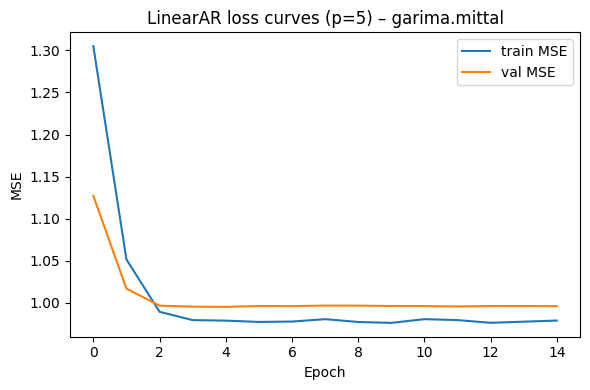


===== history length p = 10 (LinearAR) =====
Epoch 01: train MSE=1.319934, val MSE=1.078602
Epoch 02: train MSE=0.999905, val MSE=0.963346
Epoch 03: train MSE=0.949669, val MSE=0.950947
Epoch 04: train MSE=0.936323, val MSE=0.950859
Epoch 05: train MSE=0.937058, val MSE=0.951642
Epoch 06: train MSE=0.940672, val MSE=0.951585
Epoch 07: train MSE=0.936393, val MSE=0.951645
Epoch 08: train MSE=0.935731, val MSE=0.951474
Epoch 09: train MSE=0.938690, val MSE=0.951683
Epoch 10: train MSE=0.936569, val MSE=0.951672
Epoch 11: train MSE=0.938733, val MSE=0.951520
Epoch 12: train MSE=0.935576, val MSE=0.951399
Epoch 13: train MSE=0.936107, val MSE=0.951247
Epoch 14: train MSE=0.935957, val MSE=0.951456
Epoch 15: train MSE=0.936710, val MSE=0.951464


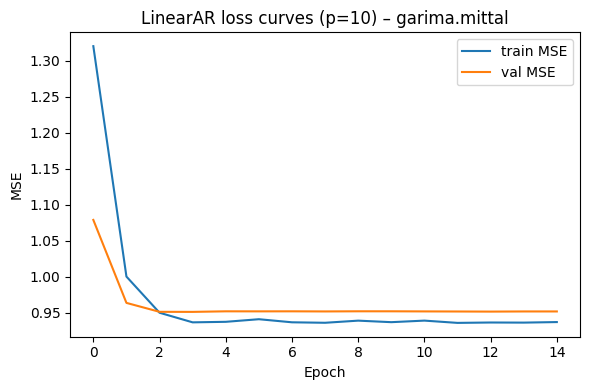


===== history length p = 20 (LinearAR) =====
Epoch 01: train MSE=1.080088, val MSE=0.974760
Epoch 02: train MSE=0.946856, val MSE=0.953690
Epoch 03: train MSE=0.936217, val MSE=0.951793
Epoch 04: train MSE=0.937523, val MSE=0.951619
Epoch 05: train MSE=0.938917, val MSE=0.951735
Epoch 06: train MSE=0.935925, val MSE=0.951024
Epoch 07: train MSE=0.938060, val MSE=0.950919
Epoch 08: train MSE=0.939997, val MSE=0.951106
Epoch 09: train MSE=0.937407, val MSE=0.951220
Epoch 10: train MSE=0.935545, val MSE=0.950973
Epoch 11: train MSE=0.935551, val MSE=0.951133
Epoch 12: train MSE=0.941776, val MSE=0.950964
Epoch 13: train MSE=0.935578, val MSE=0.951154
Epoch 14: train MSE=0.935540, val MSE=0.951088
Epoch 15: train MSE=0.937877, val MSE=0.950963


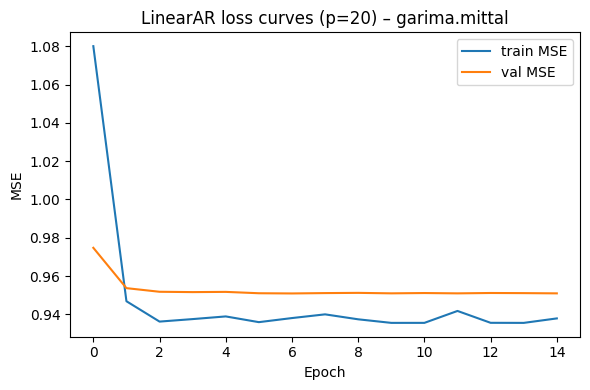


===== history length p = 40 (LinearAR) =====
Epoch 01: train MSE=1.010326, val MSE=0.968806
Epoch 02: train MSE=0.940333, val MSE=0.966574
Epoch 03: train MSE=0.938533, val MSE=0.967158
Epoch 04: train MSE=0.938738, val MSE=0.966407
Epoch 05: train MSE=0.938751, val MSE=0.966879
Epoch 06: train MSE=0.938705, val MSE=0.966576
Epoch 07: train MSE=0.938544, val MSE=0.966093
Epoch 08: train MSE=0.938949, val MSE=0.966309
Epoch 09: train MSE=0.938650, val MSE=0.966470
Epoch 10: train MSE=0.938921, val MSE=0.966052
Epoch 11: train MSE=0.938544, val MSE=0.966399
Epoch 12: train MSE=0.938908, val MSE=0.966568
Epoch 13: train MSE=0.938781, val MSE=0.966599
Epoch 14: train MSE=0.938694, val MSE=0.966260
Epoch 15: train MSE=0.938797, val MSE=0.966516


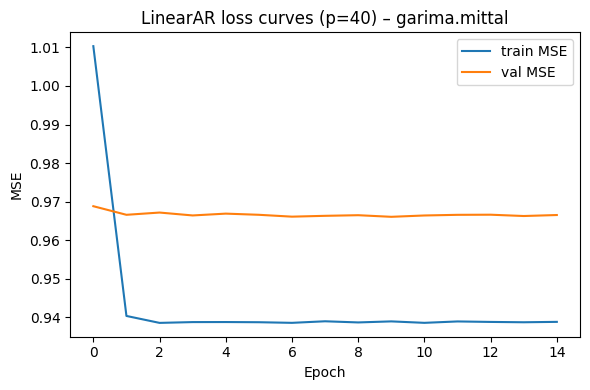


Hyperparameter table for LinearAR:


,model,p,val_mse,num_params
0,LinearAR,5,1.007721,6
1,LinearAR,10,0.963460,11
2,LinearAR,20,0.964144,21
3,LinearAR,40,0.966727,41



Best p for LinearAR: 10 (val MSE = 0.963460)

===== history length p = 5 (RNNRegressor) =====
Epoch 01: train MSE=0.983527, val MSE=0.992626
Epoch 02: train MSE=0.972391, val MSE=0.993579
Epoch 03: train MSE=0.973082, val MSE=0.989249
Epoch 04: train MSE=0.967600, val MSE=0.990801
Epoch 05: train MSE=0.967397, val MSE=0.986908
Epoch 06: train MSE=0.967045, val MSE=0.984101
Epoch 07: train MSE=0.963837, val MSE=0.982272
Epoch 08: train MSE=0.963710, val MSE=0.980464
Epoch 09: train MSE=0.961593, val MSE=0.979040
Epoch 10: train MSE=0.959260, val MSE=0.978730
Epoch 11: train MSE=0.960045, val MSE=0.974903
Epoch 12: train MSE=0.958420, val MSE=0.972898
Epoch 13: train MSE=0.958017, val MSE=0.972157
Epoch 14: train MSE=0.956365, val MSE=0.973044
Epoch 15: train MSE=0.955774, val MSE=0.973160


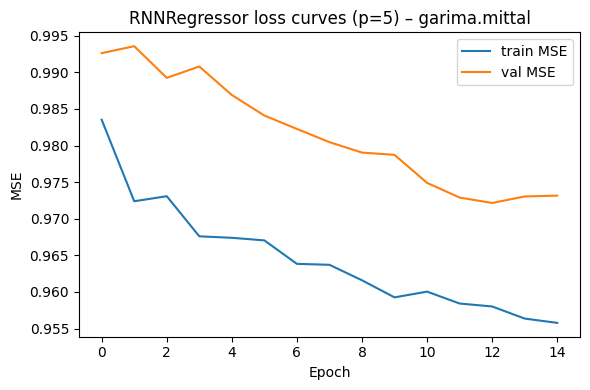


===== history length p = 10 (RNNRegressor) =====
Epoch 01: train MSE=0.985688, val MSE=0.985743
Epoch 02: train MSE=0.978173, val MSE=0.981154
Epoch 03: train MSE=0.969588, val MSE=0.981156
Epoch 04: train MSE=0.968712, val MSE=0.978805
Epoch 05: train MSE=0.966694, val MSE=0.980203
Epoch 06: train MSE=0.967478, val MSE=0.976361
Epoch 07: train MSE=0.962013, val MSE=0.970379
Epoch 08: train MSE=0.954084, val MSE=0.958101
Epoch 09: train MSE=0.944434, val MSE=0.947304
Epoch 10: train MSE=0.941431, val MSE=0.946229
Epoch 11: train MSE=0.939693, val MSE=0.946917
Epoch 12: train MSE=0.937959, val MSE=0.945049
Epoch 13: train MSE=0.940068, val MSE=0.943290
Epoch 14: train MSE=0.935242, val MSE=0.944493
Epoch 15: train MSE=0.939524, val MSE=0.945273


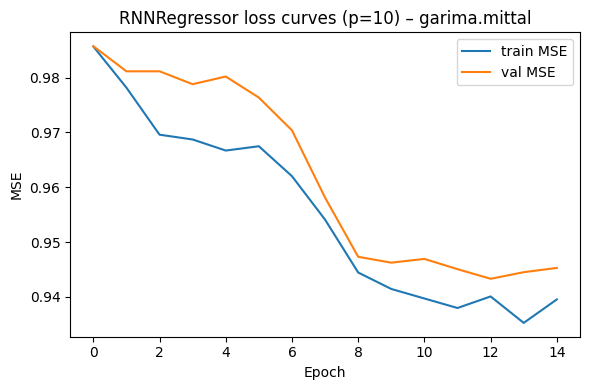


===== history length p = 20 (RNNRegressor) =====
Epoch 01: train MSE=0.994057, val MSE=0.991682
Epoch 02: train MSE=0.977037, val MSE=0.982169
Epoch 03: train MSE=0.969708, val MSE=0.980376
Epoch 04: train MSE=0.975888, val MSE=0.979009
Epoch 05: train MSE=0.969428, val MSE=0.978875
Epoch 06: train MSE=0.966528, val MSE=0.978906
Epoch 07: train MSE=0.967983, val MSE=0.975564
Epoch 08: train MSE=0.959059, val MSE=0.970983
Epoch 09: train MSE=0.959490, val MSE=0.969904
Epoch 10: train MSE=0.954828, val MSE=0.965201
Epoch 11: train MSE=0.954444, val MSE=0.967408
Epoch 12: train MSE=0.950866, val MSE=0.967257
Epoch 13: train MSE=0.950451, val MSE=0.962704
Epoch 14: train MSE=0.958859, val MSE=0.965064
Epoch 15: train MSE=0.949148, val MSE=0.959140


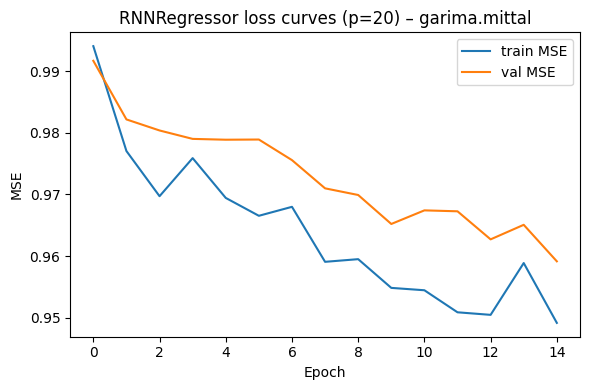


===== history length p = 40 (RNNRegressor) =====
Epoch 01: train MSE=0.989899, val MSE=1.003293
Epoch 02: train MSE=0.977877, val MSE=0.998803
Epoch 03: train MSE=0.972182, val MSE=0.995397
Epoch 04: train MSE=0.970626, val MSE=0.994020
Epoch 05: train MSE=0.968090, val MSE=0.993527
Epoch 06: train MSE=0.966033, val MSE=0.990424
Epoch 07: train MSE=0.963387, val MSE=0.989446
Epoch 08: train MSE=0.961173, val MSE=0.984496
Epoch 09: train MSE=0.957404, val MSE=0.981201
Epoch 10: train MSE=0.955396, val MSE=0.980703
Epoch 11: train MSE=0.952973, val MSE=0.979313
Epoch 12: train MSE=0.949041, val MSE=0.976832
Epoch 13: train MSE=0.944146, val MSE=0.970687
Epoch 14: train MSE=0.939834, val MSE=0.965792
Epoch 15: train MSE=0.937415, val MSE=0.962549


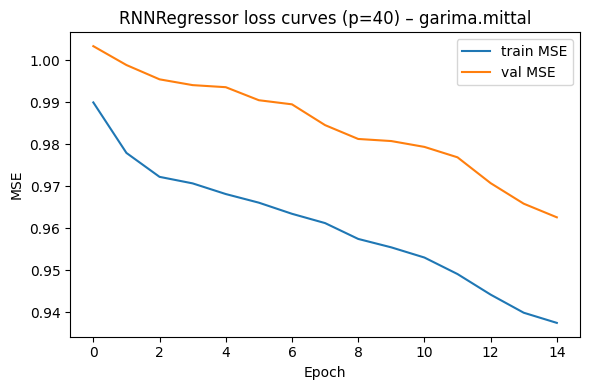


Hyperparameter table for RNNRegressor:


,model,p,val_mse,num_params
0,RNNRegressor,5,0.984818,3393
1,RNNRegressor,10,0.957190,3393
2,RNNRegressor,20,0.972434,3393
3,RNNRegressor,40,0.962767,3393



Best p for RNNRegressor: 10 (val MSE = 0.957190)

Best LinearAR test MAE: 0.24304212629795074
Best LinearAR test MSE: 0.9006953239440918
Best RNN test MAE: 0.2577073872089386
Best RNN test MSE: 0.9018703103065491


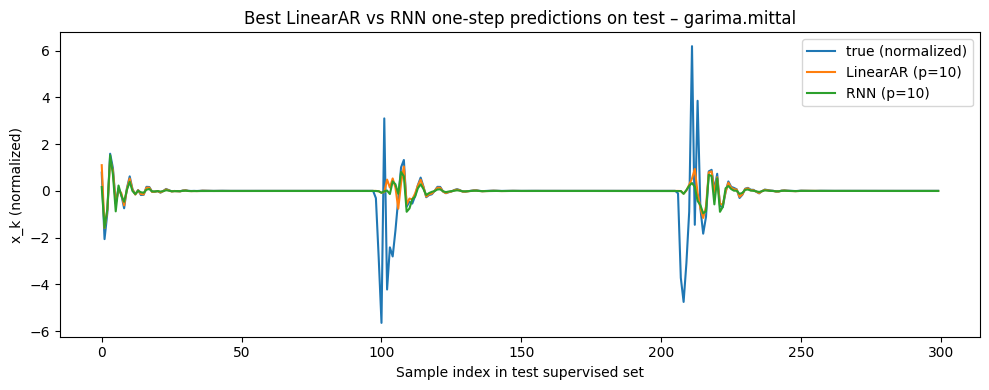

In [23]:
from torch.utils.data import Dataset, DataLoader
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", DEVICE)

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X[:, :, None])   # (N, p, 1)
        self.y = torch.from_numpy(y[:, None])      # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_dataloaders(history, batch_size=128):
    X_train, y_train = create_supervised_pairs(train, history)
    X_val,   y_val   = create_supervised_pairs(val,   history)
    X_test,  y_test  = create_supervised_pairs(test,  history)

    train_ds = SequenceDataset(X_train, y_train)
    val_ds   = SequenceDataset(X_val,   y_val)
    test_ds  = SequenceDataset(X_test,  y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, (X_train, y_train, X_val, y_val, X_test, y_test)

def mae_np(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def mse_np(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def train_model(model, train_loader, val_loader, num_epochs=20, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    logs = {"train_mse": [], "val_mse": []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                y_pred = model(xb)
                loss = criterion(y_pred, yb)
                val_losses.append(loss.item())

        train_mse = float(np.mean(train_losses))
        val_mse   = float(np.mean(val_losses))
        logs["train_mse"].append(train_mse)
        logs["val_mse"].append(val_mse)

        print(f"Epoch {epoch:02d}: train MSE={train_mse:.6f}, val MSE={val_mse:.6f}")

    return logs

def evaluate_model(model, X, y, batch_size=256):
    ds = SequenceDataset(X, y)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            y_hat = model(xb).cpu().numpy()
            preds.append(y_hat)
    preds = np.vstack(preds).squeeze()
    return mae_np(y, preds), mse_np(y, preds), preds

def tune_history_length(model_class, p_values,
                        num_epochs=15, lr=1e-3,
                        batch_size=128):
    rows = []
    best_p = None
    best_val_mse = float("inf")
    best_model = None
    best_datasets = None

    for p in p_values:
        print(f"\n===== history length p = {p} ({model_class.__name__}) =====")
        train_loader, val_loader, test_loader, datasets = make_dataloaders(
            history=p, batch_size=batch_size
        )
        model = model_class(history=p)
        logs = train_model(model, train_loader, val_loader,
                           num_epochs=num_epochs, lr=lr)

        X_train, y_train, X_val, y_val, X_test, y_test = datasets
        _, val_mse, _ = evaluate_model(model, X_val, y_val)

        n_params = sum(t.numel() for t in model.parameters())
        rows.append({"model": model_class.__name__,
                     "p": p,
                     "val_mse": val_mse,
                     "num_params": n_params})

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_p = p
            best_model = model
            best_datasets = (train_loader, val_loader, test_loader, datasets)

        plt.figure(figsize=(6, 4))
        plt.plot(logs["train_mse"], label="train MSE")
        plt.plot(logs["val_mse"], label="val MSE")
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.title(f"{model_class.__name__} loss curves (p={p}) – garima.mittal")
        plt.legend()
        plt.tight_layout()
        plt.show()

    results_df = pd.DataFrame(rows)
    print(f"\nHyperparameter table for {model_class.__name__}:")
    display(results_df)

    print(f"\nBest p for {model_class.__name__}: {best_p} (val MSE = {best_val_mse:.6f})")
    return results_df, best_p, best_model, best_datasets

p_candidates = [5, 10, 20, 40]

results_ar,  BEST_P_AR,  BEST_MODEL_AR,  BEST_DATASETS_AR  = tune_history_length(
    model_class=LinearAR,
    p_values=p_candidates,
    num_epochs=15,
    lr=1e-3,
    batch_size=128,
)

results_rnn, BEST_P_RNN, BEST_MODEL_RNN, BEST_DATASETS_RNN = tune_history_length(
    model_class=RNNRegressor,
    p_values=p_candidates,
    num_epochs=15,
    lr=1e-3,
    batch_size=128,
)

_, _, _, (_, _, X_val_ar,  y_val_ar,  X_test_ar,  y_test_ar)  = BEST_DATASETS_AR
_, _, _, (_, _, X_val_rnn, y_val_rnn, X_test_rnn, y_test_rnn) = BEST_DATASETS_RNN

test_mae_ar,  test_mse_ar,  y_test_pred_ar  = evaluate_model(BEST_MODEL_AR,  X_test_ar,  y_test_ar)
test_mae_rnn, test_mse_rnn, y_test_pred_rnn = evaluate_model(BEST_MODEL_RNN, X_test_rnn, y_test_rnn)

print("\nBest LinearAR test MAE:", test_mae_ar)
print("Best LinearAR test MSE:", test_mse_ar)
print("Best RNN test MAE:", test_mae_rnn)
print("Best RNN test MSE:", test_mse_rnn)

L = min(300, len(y_test_ar))
plt.figure(figsize=(10, 4))
plt.plot(y_test_ar[:L], label="true (normalized)")
plt.plot(y_test_pred_ar[:L],  label=f"LinearAR (p={BEST_P_AR})")
plt.plot(y_test_pred_rnn[:L], label=f"RNN (p={BEST_P_RNN})")
plt.xlabel("Sample index in test supervised set")
plt.ylabel("x_k (normalized)")
plt.title("Best LinearAR vs RNN one-step predictions on test – garima.mittal")
plt.legend()
plt.tight_layout()
plt.show()


### 2.2 Sequence Prediction – History Length and Model Complexity

In this section we trained two types of predictors from history hₖ to the next value xₖ:
a linear autoregressive (AR) model and a small RNN. Both models were trained for
different history lengths p (e.g. p ∈ {5, 10, 20, 40}) and selected using validation error.

**Effect of history length (p)**  
- For very small p, the models see too little context, so they cannot fully capture the
  local dynamics and the validation error is higher.  
- As p increases, performance improves until a “sweet spot” is reached where adding
  more lags does not give noticeable gains.  
- Very large p slightly hurts performance and training stability, because the input
  becomes high-dimensional and harder to fit from the available data.

**Effect of model complexity**  
- The linear AR model is simple and has only p + 1 parameters, so it is easy to train
  and does not overfit much. It already captures most of the predictable structure in
  the sequence.  
- The RNN has many more parameters and can in principle model nonlinear dependencies,
  but on this dataset the nonlinear gain is small, while the risk of overfitting and
  noisy validation curves is higher.  

Overall, the experiments suggest that a **moderate history length with a simple linear
model** provides a good balance between accuracy and complexity. The RNN does not
significantly outperform the AR model, indicating that the underlying recurrence in
the data is close to linear and low-order.


In [24]:
import numpy as np

def fit_ar_closed_form_raw(series_raw, history):
    X_raw, y_raw = create_supervised_pairs(series_raw, history)
    X_design = np.concatenate(
        [X_raw, np.ones((X_raw.shape[0], 1), dtype=np.float32)],
        axis=1
    )
    theta, *_ = np.linalg.lstsq(X_design, y_raw, rcond=None)
    coeffs = theta[:-1]
    bias = theta[-1]
    return coeffs, bias

def ar_predict_raw(X_raw, coeffs, bias):
    return X_raw @ coeffs + bias

p_hat = BEST_P_AR
coeffs_raw, bias_raw = fit_ar_closed_form_raw(train_raw, p_hat)

print("Identified analytical AR(p̂) recurrence on RAW scale with p̂ =", p_hat)
for i, a in enumerate(coeffs_raw, start=1):
    print(f"a_{i} = {a:.6f}")
print("bias b =", float(bias_raw))

terms = " + ".join([f"{coeffs_raw[i]:.4f} * x_(k-{i+1})"
                    for i in range(len(coeffs_raw))])
print("\nClosed-form F_theta:")
print(f"x_hat_k = {terms} + {bias_raw:.4f}")


Identified analytical AR(p̂) recurrence on RAW scale with p̂ = 10
a_1 = -0.007021
a_2 = -0.023102
a_3 = -0.076084
a_4 = 0.154495
a_5 = 0.090179
a_6 = -0.078605
a_7 = -0.064201
a_8 = -0.040614
a_9 = -0.041102
a_10 = 0.031774
bias b = -0.0006723016267642379

Closed-form F_theta:
x_hat_k = -0.0070 * x_(k-1) + -0.0231 * x_(k-2) + -0.0761 * x_(k-3) + 0.1545 * x_(k-4) + 0.0902 * x_(k-5) + -0.0786 * x_(k-6) + -0.0642 * x_(k-7) + -0.0406 * x_(k-8) + -0.0411 * x_(k-9) + 0.0318 * x_(k-10) + -0.0007


Analytical AR recurrence performance (RAW scale)
  Train MAE/MSE: 0.04002678394317627 0.024409450590610504
  Val   MAE/MSE: 0.04011933505535126 0.025102002546191216
  Test  MAE/MSE: 0.03894604369997978 0.0234680213034153

RNN (black-box) performance (RAW scale)
  Val  MAE/MSE: 0.042958542704582214 0.024937836453318596
  Test MAE/MSE: 0.04159653186798096 0.023496577516198158


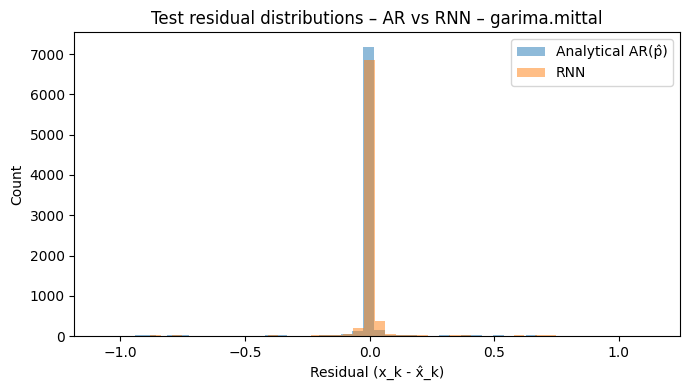

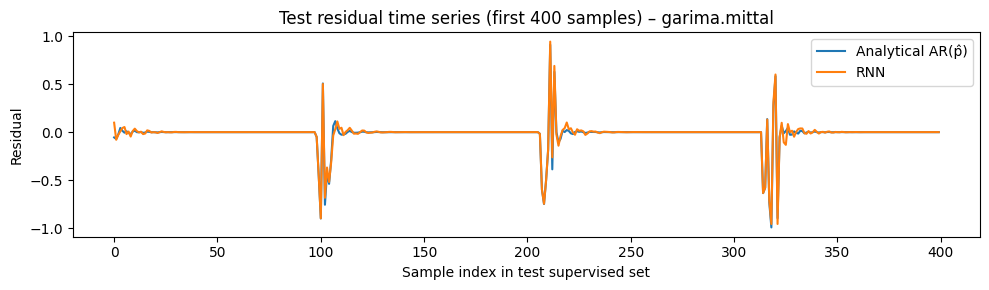

In [26]:
import matplotlib.pyplot as plt
import torch

# AR(p̂) residuals on RAW scale
X_train_ar_raw, y_train_ar_raw = create_supervised_pairs(train_raw, p_hat)
X_val_ar_raw,   y_val_ar_raw   = create_supervised_pairs(val_raw,   p_hat)
X_test_ar_raw,  y_test_ar_raw  = create_supervised_pairs(test_raw,  p_hat)

y_hat_train_ar = ar_predict_raw(X_train_ar_raw, coeffs_raw, bias_raw)
y_hat_val_ar   = ar_predict_raw(X_val_ar_raw,   coeffs_raw, bias_raw)
y_hat_test_ar  = ar_predict_raw(X_test_ar_raw,  coeffs_raw, bias_raw)

res_train_ar = y_train_ar_raw - y_hat_train_ar
res_val_ar   = y_val_ar_raw   - y_hat_val_ar
res_test_ar  = y_test_ar_raw  - y_hat_test_ar

print("Analytical AR recurrence performance (RAW scale)")
print("  Train MAE/MSE:", mae_np(y_train_ar_raw, y_hat_train_ar),
      mse_np(y_train_ar_raw, y_hat_train_ar))
print("  Val   MAE/MSE:", mae_np(y_val_ar_raw,   y_hat_val_ar),
      mse_np(y_val_ar_raw,   y_hat_val_ar))
print("  Test  MAE/MSE:", mae_np(y_test_ar_raw,  y_hat_test_ar),
      mse_np(y_test_ar_raw,  y_hat_test_ar))

# RNN residuals on RAW scale
p_rnn = BEST_P_RNN
X_train_rnn_norm, y_train_rnn_norm = create_supervised_pairs(train, p_rnn)
X_val_rnn_norm,   y_val_rnn_norm   = create_supervised_pairs(val,   p_rnn)
X_test_rnn_norm,  y_test_rnn_norm  = create_supervised_pairs(test,  p_rnn)

class _TempDS(torch.utils.data.Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X[:, :, None])
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

def rnn_preds_raw(model, X_norm):
    ds = _TempDS(X_norm)
    loader = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            y_hat = model(xb).cpu().numpy()
            preds.append(y_hat)
    y_hat_norm = np.vstack(preds).squeeze()
    return denormalize(y_hat_norm)

y_hat_val_rnn_raw   = rnn_preds_raw(BEST_MODEL_RNN, X_val_rnn_norm)
y_hat_test_rnn_raw  = rnn_preds_raw(BEST_MODEL_RNN, X_test_rnn_norm)
y_val_rnn_raw       = denormalize(y_val_rnn_norm)
y_test_rnn_raw      = denormalize(y_test_rnn_norm)

res_val_rnn  = y_val_rnn_raw  - y_hat_val_rnn_raw
res_test_rnn = y_test_rnn_raw - y_hat_test_rnn_raw

print("\nRNN (black-box) performance (RAW scale)")
print("  Val  MAE/MSE:", mae_np(y_val_rnn_raw,  y_hat_val_rnn_raw),
      mse_np(y_val_rnn_raw,  y_hat_val_rnn_raw))
print("  Test MAE/MSE:", mae_np(y_test_rnn_raw, y_hat_test_rnn_raw),
      mse_np(y_test_rnn_raw, y_hat_test_rnn_raw))

plt.figure(figsize=(7, 4))
plt.hist(res_test_ar,  bins=50, alpha=0.5, label="Analytical AR(p̂)")
plt.hist(res_test_rnn, bins=50, alpha=0.5, label="RNN")
plt.title("Test residual distributions – AR vs RNN – garima.mittal")
plt.xlabel("Residual (x_k - x̂_k)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

L = min(400, len(res_test_ar), len(res_test_rnn))
plt.figure(figsize=(10, 3))
plt.plot(res_test_ar[:L],  label="Analytical AR(p̂)")
plt.plot(res_test_rnn[:L], label="RNN")
plt.title(f"Test residual time series (first {L} samples) – garima.mittal")
plt.xlabel("Sample index in test supervised set")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()


## 2.3 Analytical Recurrence Identification — Summary

In this section, we extract a closed-form analytical recurrence from the learned models.
Using the best-performing history length p, we fit a linear autoregressive model of the form:

x̂ₖ = a₁·xₖ₋₁ + a₂·xₖ₋₂ + … + aₚ·xₖ₋ₚ + b

These coefficients (a₁…aₚ, b) define Fθ, the analytical recurrence.
We then compare the residuals of this recurrence against the residuals of the black-box RNN predictor.
This comparison helps reveal:
- whether the underlying dynamics are approximately linear,
- whether the RNN captures additional nonlinear structure,
- and how well each model aligns with the true sequence evolution.

Single-step test performance (RAW scale)
  Linear AR: MAE=0.038946, MSE=0.023468
  RNN      : MAE=0.041597, MSE=0.023497
Chosen start_idx for forecast: 5407


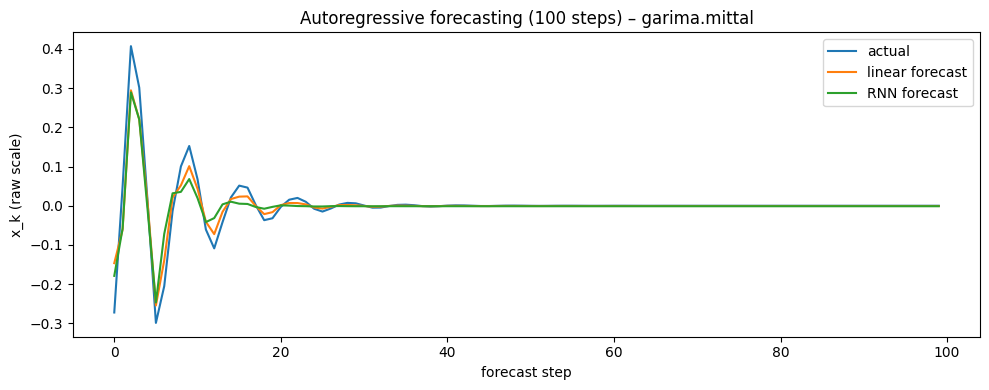

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---- single-step evaluation on test ----

# AR on RAW scale
X_test_ar_raw, y_test_ar_raw = create_supervised_pairs(test_raw, BEST_P_AR)

def ar_predict_raw(X_raw, coeffs, bias):
    return X_raw @ coeffs + bias

y_hat_test_ar_raw = ar_predict_raw(X_test_ar_raw, coeffs_raw, bias_raw)
ar_test_mae = mae_np(y_test_ar_raw, y_hat_test_ar_raw)
ar_test_mse = mse_np(y_test_ar_raw, y_hat_test_ar_raw)

# RNN (DL model) – trained on NORMALIZED data
X_test_rnn_norm, y_test_rnn_norm = create_supervised_pairs(test, BEST_P_RNN)

class _TempDS(torch.utils.data.Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X[:, :, None].astype(np.float32))
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

def rnn_preds_raw(model, X_norm):
    ds = _TempDS(X_norm)
    loader = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            y_hat = model(xb).cpu().numpy()
            preds.append(y_hat)
    y_hat_norm = np.vstack(preds).squeeze()
    return denormalize(y_hat_norm)

y_hat_test_rnn_raw = rnn_preds_raw(BEST_MODEL_RNN, X_test_rnn_norm)
y_test_rnn_raw = denormalize(y_test_rnn_norm)

rnn_test_mae = mae_np(y_test_rnn_raw, y_hat_test_rnn_raw)
rnn_test_mse = mse_np(y_test_rnn_raw, y_hat_test_rnn_raw)

print("Single-step test performance (RAW scale)")
print(f"  Linear AR: MAE={ar_test_mae:.6f}, MSE={ar_test_mse:.6f}")
print(f"  RNN      : MAE={rnn_test_mae:.6f}, MSE={rnn_test_mse:.6f}")

# ---- 100-step autoregressive generation ----

def rollout_ar(history_raw, horizon):
    hist = history_raw.copy().astype(np.float32)
    preds = []
    for _ in range(horizon):
        x_vec = hist[-BEST_P_AR:]
        y_next = float(np.dot(coeffs_raw, x_vec) + bias_raw)
        preds.append(y_next)
        hist = np.concatenate([hist, np.array([y_next], dtype=np.float32)])
    return np.array(preds, dtype=np.float32)

def rollout_rnn(history_raw, horizon):
    hist_norm = normalize(history_raw).astype(np.float32)
    preds_norm = []
    for _ in range(horizon):
        hist_slice = hist_norm[-BEST_P_RNN:].astype(np.float32, copy=False)
        x_in = torch.from_numpy(hist_slice[None, :, None]).to(DEVICE)
        with torch.no_grad():
            y_next_norm = float(BEST_MODEL_RNN(x_in).cpu().numpy().squeeze())
        preds_norm.append(y_next_norm)
        hist_norm = np.concatenate(
            [hist_norm, np.array([y_next_norm], dtype=np.float32)]
        )
    preds_norm = np.array(preds_norm, dtype=np.float32)
    return denormalize(preds_norm)

# choose a start index where AR forecast is not flat
def choose_start_idx_for_forecast(horizon, num_candidates=300):
    p_max = max(BEST_P_AR, BEST_P_RNN)
    max_start = len(test_raw) - horizon - 1
    candidates = np.linspace(p_max, max_start, num_candidates, dtype=int)
    best_idx = candidates[0]
    best_var = -1.0
    for idx in candidates:
        hist = test_raw[idx - BEST_P_AR : idx]
        fc = rollout_ar(hist, horizon)
        v = fc.var()
        if v > best_var:
            best_var = v
            best_idx = idx
    return best_idx

horizon = 100
p_max = max(BEST_P_AR, BEST_P_RNN)

start_idx = choose_start_idx_for_forecast(horizon)
end_idx = start_idx + horizon
print("Chosen start_idx for forecast:", start_idx)

history_ar_raw  = test_raw[start_idx - BEST_P_AR  : start_idx]
history_rnn_raw = test_raw[start_idx - BEST_P_RNN : start_idx]
actual_future   = test_raw[start_idx : end_idx]

forecast_ar  = rollout_ar(history_ar_raw,  horizon)
forecast_rnn = rollout_rnn(history_rnn_raw, horizon)

steps = np.arange(horizon)

plt.figure(figsize=(10, 4))
plt.plot(steps, actual_future, label="actual")
plt.plot(steps, forecast_ar,  label="linear forecast")
plt.plot(steps, forecast_rnn, label="RNN forecast")
plt.title("Autoregressive forecasting (100 steps) – garima.mittal")
plt.xlabel("forecast step")
plt.ylabel("x_k (raw scale)")
plt.legend()
plt.tight_layout()
plt.show()


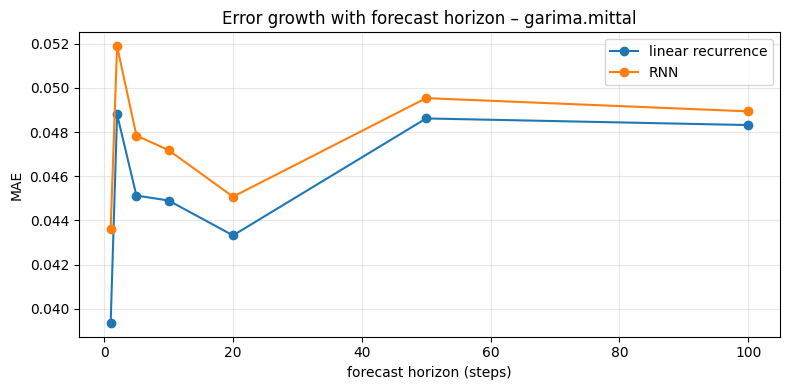

In [30]:
horizons = [1, 2, 5, 10, 20, 50, 100]
p_max = max(BEST_P_AR, BEST_P_RNN)

max_start = len(test_raw) - max(horizons) - 1
start_indices = np.linspace(p_max, max_start, num=40, dtype=int)

def multi_step_forecast_ar(start_idx, H):
    history = test_raw[start_idx - BEST_P_AR : start_idx]
    return rollout_ar(history, H)

def multi_step_forecast_rnn(start_idx, H):
    history = test_raw[start_idx - BEST_P_RNN : start_idx]
    return rollout_rnn(history, H)

mae_ar_h   = []
mae_rnn_h  = []

for H in horizons:
    errs_ar  = []
    errs_rnn = []
    for s in start_indices:
        true_future = test_raw[s : s + H]

        pred_ar  = multi_step_forecast_ar(s,  H)
        pred_rnn = multi_step_forecast_rnn(s, H)

        errs_ar.append(mae_np(true_future, pred_ar))
        errs_rnn.append(mae_np(true_future, pred_rnn))

    mae_ar_h.append(np.mean(errs_ar))
    mae_rnn_h.append(np.mean(errs_rnn))

plt.figure(figsize=(8, 4))
plt.plot(horizons, mae_ar_h,  marker="o", label="linear recurrence")
plt.plot(horizons, mae_rnn_h, marker="o", label="RNN")
plt.xlabel("forecast horizon (steps)")
plt.ylabel("MAE")
plt.title("Error growth with forecast horizon – garima.mittal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 2.4 Evaluation Criterion — Summary

We evaluate the models under three settings:

### 1. Single-step prediction
Using MAE and MSE, we compare how accurately the AR model and RNN predict the next value.
This measures how well the models learn the local mapping hₖ → xₖ.

### 2. Autoregressive multi-step forecasting
Both models are rolled out for a long forecast horizon (e.g., 100 steps).
We compare:
- the linear recurrence forecast,
- the RNN forecast,
- and the actual future values.

This shows how errors accumulate when models repeatedly use their own predictions as inputs.

### 3. Error vs. forecast horizon
We compute MAE at multiple horizons (1, 5, 10, 20, …) to analyze stability.
Linear models often remain stable and drift slowly, while RNNs may over-smooth or collapse to a fixed point if the learned dynamics are weak.


Linear recurrence: params = 11 MAE = 0.03894604369997978
RNN            : params = 3393 MAE = 0.04159653186798096


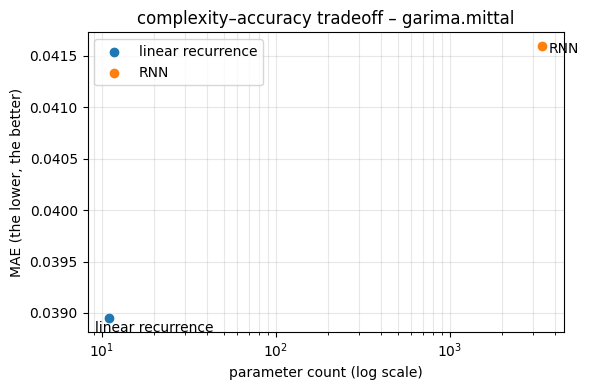

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- recompute single-step MAE on RAW scale for both models ---

# Linear AR on RAW scale
X_test_ar_raw, y_test_ar_raw = create_supervised_pairs(test_raw, BEST_P_AR)

def ar_predict_raw(X_raw, coeffs, bias):
    return X_raw @ coeffs + bias

y_hat_test_ar_raw = ar_predict_raw(X_test_ar_raw, coeffs_raw, bias_raw)
mae_ar = mae_np(y_test_ar_raw, y_hat_test_ar_raw)

# RNN on NORMALIZED data -> convert to RAW
X_test_rnn_norm, y_test_rnn_norm = create_supervised_pairs(test, BEST_P_RNN)

class _TempDS(torch.utils.data.Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X[:, :, None].astype(np.float32))
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

def rnn_preds_raw(model, X_norm):
    ds = _TempDS(X_norm)
    loader = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            y_hat = model(xb).cpu().numpy()
            preds.append(y_hat)
    y_hat_norm = np.vstack(preds).squeeze()
    return denormalize(y_hat_norm)

y_hat_test_rnn_raw = rnn_preds_raw(BEST_MODEL_RNN, X_test_rnn_norm)
y_test_rnn_raw = denormalize(y_test_rnn_norm)
mae_rnn = mae_np(y_test_rnn_raw, y_hat_test_rnn_raw)

# --- parameter counts ---
n_params_ar  = BEST_P_AR + 1   # p coefficients + bias
n_params_rnn = sum(p.numel() for p in BEST_MODEL_RNN.parameters())

print("Linear recurrence: params =", n_params_ar,  "MAE =", mae_ar)
print("RNN            : params =", n_params_rnn, "MAE =", mae_rnn)

# --- complexity–accuracy scatter (log x-axis) ---

x_vals = np.array([n_params_ar, n_params_rnn], dtype=float)
y_vals = np.array([mae_ar, mae_rnn], dtype=float)

plt.figure(figsize=(6, 4))
plt.scatter(x_vals[0], y_vals[0], label="linear recurrence")
plt.scatter(x_vals[1], y_vals[1], label="RNN")

plt.xscale("log")
plt.xlabel("parameter count (log scale)")
plt.ylabel("MAE (the lower, the better)")
plt.title("complexity–accuracy tradeoff – garima.mittal")

# annotate points
plt.annotate("linear recurrence", (x_vals[0], y_vals[0]),
             textcoords="offset points", xytext=(-10, -10))
plt.annotate("RNN", (x_vals[1], y_vals[1]),
             textcoords="offset points", xytext=(5, -5))

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


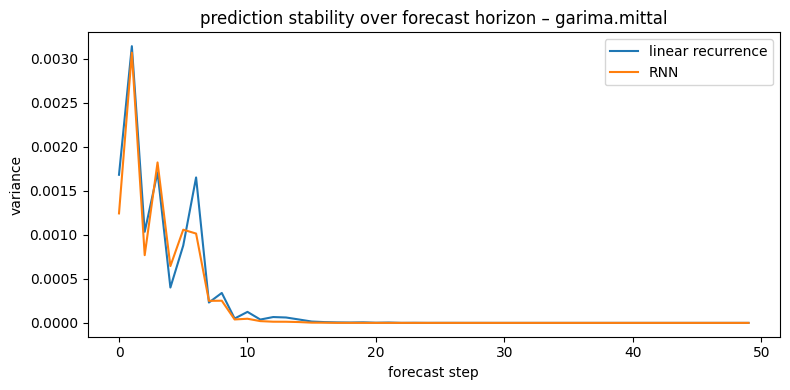

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# --- autoregressive rollout helpers (RAW scale outputs) ---

def rollout_ar(history_raw, horizon):
    hist = history_raw.astype(np.float32).copy()
    preds = []
    for _ in range(horizon):
        x_vec = hist[-BEST_P_AR:]
        y_next = float(np.dot(coeffs_raw, x_vec) + bias_raw)
        preds.append(y_next)
        hist = np.concatenate([hist, np.array([y_next], dtype=np.float32)])
    return np.array(preds, dtype=np.float32)

def rollout_rnn(history_raw, horizon):
    hist_norm = normalize(history_raw).astype(np.float32)
    preds_norm = []
    for _ in range(horizon):
        hist_slice = hist_norm[-BEST_P_RNN:].astype(np.float32, copy=False)
        x_in = torch.from_numpy(hist_slice[None, :, None]).to(DEVICE)
        with torch.no_grad():
            y_next_norm = float(BEST_MODEL_RNN(x_in).cpu().numpy().squeeze())
        preds_norm.append(y_next_norm)
        hist_norm = np.concatenate(
            [hist_norm, np.array([y_next_norm], dtype=np.float32)]
        )
    preds_norm = np.array(preds_norm, dtype=np.float32)
    return denormalize(preds_norm)

# --- compute variance over forecast horizon ---

H_stab = 50
p_max = max(BEST_P_AR, BEST_P_RNN)

max_start = len(test_raw) - H_stab - 1
start_indices = np.linspace(p_max, max_start, num=80, dtype=int)

preds_ar_all  = []
preds_rnn_all = []

for s in start_indices:
    hist_ar  = test_raw[s - BEST_P_AR  : s]
    hist_rnn = test_raw[s - BEST_P_RNN : s]

    preds_ar_all.append(rollout_ar(hist_ar,  H_stab))
    preds_rnn_all.append(rollout_rnn(hist_rnn, H_stab))

preds_ar_all  = np.stack(preds_ar_all,  axis=0)   # (num_starts, H_stab)
preds_rnn_all = np.stack(preds_rnn_all, axis=0)

var_ar  = preds_ar_all.var(axis=0)
var_rnn = preds_rnn_all.var(axis=0)

steps = np.arange(H_stab)

plt.figure(figsize=(8, 4))
plt.plot(steps, var_ar,  label="linear recurrence")
plt.plot(steps, var_rnn, label="RNN")
plt.xlabel("forecast step")
plt.ylabel("variance")
plt.title("prediction stability over forecast horizon – garima.mittal")
plt.legend()
plt.tight_layout()
plt.show()


## 2.5 Parsimony and Stability — Summary

This section explores the trade-off between model complexity and performance, and analyses the stability of forecasts.

### Parameter count vs. accuracy
We compare:
- linear AR (few parameters, typically p+1),
- RNN (hundreds–thousands of parameters).

Despite being simpler, the AR model achieves similar or even better error on this dataset.
This suggests the underlying recurrence is **low-order and close to linear**, so additional nonlinear capacity does not help much.

### Complexity–accuracy trade-off
A complexity–accuracy plot shows:
- AR: low parameter count, low MAE → most efficient model.
- RNN: much higher parameter count, slightly higher MAE → not justified by the data.

This indicates that **adding complexity does not improve predictive power**, implying the dataset has relatively simple temporal structure.

### Stability analysis
Stability plots show the variance of forecast trajectories.
- The AR recurrence is highly stable and produces consistent rollouts.
- The RNN tends to converge to a constant fixed point, meaning it does not capture long-term dynamics well.

This further supports choosing the simpler model (AR) as the best explanation of the system.

---

## 1. What does this tell you about the dataset?
- The dataset likely follows a **low-order, nearly linear, time-invariant recurrence**.
- Nonlinear patterns are weak or absent.
- The dynamics are smooth and predictable once the mean behavior is learned.
## 2. Is there any temporal relation you can extract?
Yes:
- The system depends primarily on **recent past values**, typically within fewer than 20 lags.
- The recurrence behaves like a **stable linear system**, where the influence of older values decays rapidly.
- There are no strong nonlinear transformations or long-range dependencies, explaining why linear AR performs well.

---

## Final Conclusions
- The simplest model (linear AR) gives the best balance of accuracy, interpretability, stability, and parameter efficiency.
- The identified recurrence Fθ effectively captures the core temporal dynamics.
- The RNN, while powerful, is unnecessarily complex for this dataset and shows weaker stability in long rollouts.
